In [30]:
import numpy as np
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from scipy.special import expit  # sigmoid

In [31]:
# helpers
def binomial(n_samples, theta_like=0.7, seed=20):
    np.random.seed(seed)
    data = np.random.binomial(n_samples, theta_like)
    return data

from modulars import load_config

def _logistic_normal_mean_std_mc(mu, sigma, n_samples=200_000, seed=123, antithetic=True):
    mu = float(np.squeeze(mu))
    sigma = float(np.squeeze(sigma))
    rng = np.random.default_rng(seed)

    if antithetic:
        half = int(np.ceil(n_samples / 2))
        eps_half = rng.normal(size=half)
        eps = np.concatenate([eps_half, -eps_half], axis=0)[:n_samples]
    else:
        eps = rng.normal(size=n_samples)

    z = mu + sigma * eps
    theta = expit(z)
    return float(theta.mean()), float(theta.std(ddof=1))

@jax.jit
def _chunk_theta_moments_mc(loc_chunk, scale_chunk, eps):
    z = loc_chunk[:, None] + scale_chunk[:, None] * eps
    theta = jax.nn.sigmoid(z)
    mean = jnp.mean(theta, axis=1)
    std = jnp.std(theta, axis=1, ddof=1)
    return mean, std


def _trace_locscale_to_theta_moments(
    loc_trace,
    scale_trace,
    n_samples=200_000,
    seed=123,
    antithetic=True,
    common_random_numbers=True,
    batch_size=5000,
):
    """MC push-forward transform with optional antithetic and common-random-numbers variance reduction."""
    loc_trace = jnp.asarray(loc_trace, dtype=jnp.float32)
    scale_trace = jnp.asarray(scale_trace, dtype=jnp.float32)

    T = loc_trace.shape[0]
    n_batches = (T + batch_size - 1) // batch_size

    pad = n_batches * batch_size - T
    if pad > 0:
        loc_trace = jnp.pad(loc_trace, (0, pad))
        scale_trace = jnp.pad(scale_trace, (0, pad))

    loc_chunks = loc_trace.reshape(n_batches, batch_size)
    scale_chunks = scale_trace.reshape(n_batches, batch_size)

    key = jax.random.PRNGKey(seed)
    if antithetic:
        half = (n_samples + 1) // 2
        eps_half = jax.random.normal(
            key,
            shape=(1 if common_random_numbers else batch_size, half),
            dtype=loc_trace.dtype,
        )
        eps = jnp.concatenate([eps_half, -eps_half], axis=1)[:, :n_samples]
    else:
        eps = jax.random.normal(
            key,
            shape=(1 if common_random_numbers else batch_size, n_samples),
            dtype=loc_trace.dtype,
        )

    if common_random_numbers:
        eps = jnp.broadcast_to(eps, (batch_size, eps.shape[1]))

    def scan_fn(carry, xs):
        loc_chunk, scale_chunk = xs
        mean_chunk, std_chunk = _chunk_theta_moments_mc(
            loc_chunk, scale_chunk, eps
        )
        return carry, (mean_chunk, std_chunk)

    _, (mean_chunks, std_chunks) = jax.lax.scan(
        scan_fn,
        None,
        (loc_chunks, scale_chunks),
    )

    out_mean = mean_chunks.reshape(-1)[:T]
    out_std = std_chunks.reshape(-1)[:T]
    return np.asarray(out_mean), np.asarray(out_std)

data_gen = binomial


In [32]:
config_file = "../beta_config.json"
config = load_config(config_file)

theta_like = config['theta_like']
alpha_prior = config['alpha_prior']
beta_prior = config['beta_prior']
n_samples = config['n_samples']

data = data_gen(n_samples) if n_samples > 0 else 0
# print parameters
print("prior: Beta({}, {})".format(alpha_prior, beta_prior))
print("Likelihood: Binomial({})".format(theta_like))
print(data)
# true_post = beta_posterior(data, n_samples, alpha_prior, beta_prior)
# print("True posterior: Beta({}, {:.2f})".format(true_post['alpha_post'], true_post['beta_post']) + " with mean {:.2f} and std {:.2f}".format(true_post['mean_post'], true_post['std_post']))
# Note that our plots do compare to the "best variational approximation"

prior: Beta(0.5, 0.6)
Likelihood: Binomial(0.7)
7


In [33]:
# copy-pasted from beta_numpyro.ipynb
# run in numpyro

def model(y):
    theta = numpyro.sample("theta", dist.Beta(alpha_prior, beta_prior))
    numpyro.sample("obs", dist.Binomial(n_samples, theta), obs=y)


In [34]:
from modulars import run_restart_1d
results = []
for seed in tqdm(range(100)):
    result = run_restart_1d(seed, model, data, 'theta', 100_000, n_particles=100)
    results.append(result)


  0%|          | 0/100 [00:00<?, ?it/s]

In [35]:

# ----------------------------
# unpack results -> stacks also transform
# ----------------------------
single_means, single_stds = [], []
multi_means,  multi_stds  = [], []

for single_elbo, single_tracker, multi_elbo, multi_tracker in tqdm(results):
    # low-noise push-forward MC with variance reduction
    single_mu, single_sigma = _trace_locscale_to_theta_moments(
        single_tracker['mu_loc'][:20000],
        single_tracker['std_loc'][:20000],
        n_samples=200_000,
        seed=123,
        antithetic=True,
        common_random_numbers=True,
    )
    multi_mu, multi_sigma = _trace_locscale_to_theta_moments(
        multi_tracker['mu_loc'][:20000],
        multi_tracker['std_loc'][:20000],
        n_samples=200_000,
        seed=123,
        antithetic=True,
        common_random_numbers=True,
    )

    single_means.append(single_mu)
    single_stds.append(single_sigma)
    multi_means.append(multi_mu)
    multi_stds.append(multi_sigma)

# stack to (N, T)
from modulars import stack_trajectories
single_means, single_stds, multi_means, multi_stds = \
    stack_trajectories([single_means, single_stds, multi_means, multi_stds])

N, T = single_means.shape
x = np.arange(T)

# If you have "best" from config, these should be on theta-scale (0,1)
best_mu = float(config["best_mean"]) if "config" in globals() and "best_mean" in config else None
best_std = float(config["best_std"]) if "config" in globals() and "best_std" in config else None
best_mu, best_std = _logistic_normal_mean_std_mc(
    best_mu, best_std, n_samples=1_000_000, seed=123, antithetic=True
)


  0%|          | 0/100 [00:00<?, ?it/s]

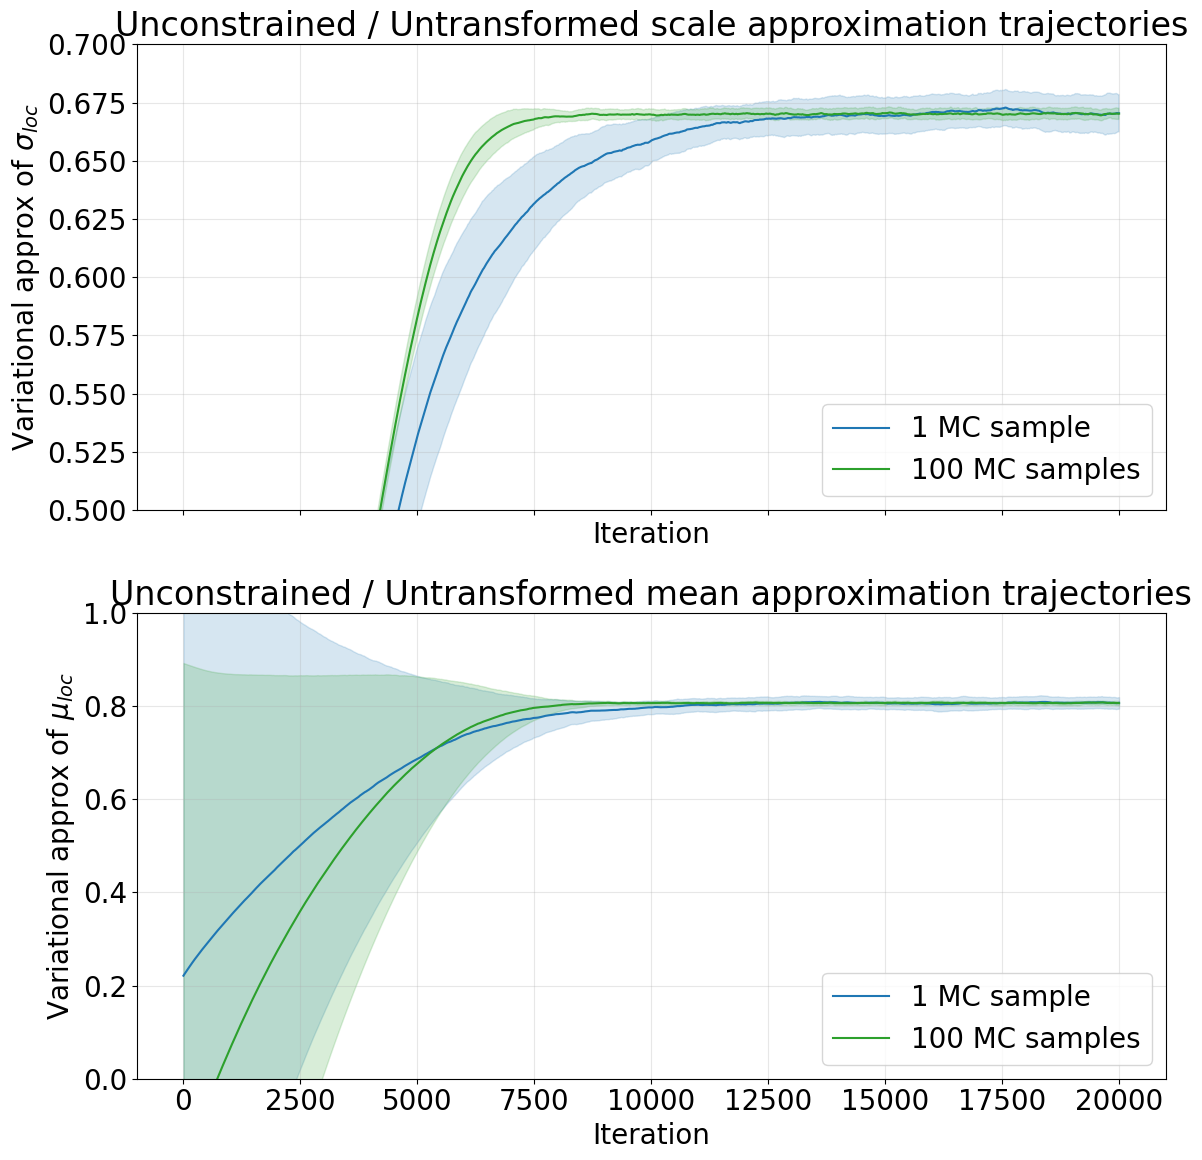

In [36]:
# ----------------------------
# Diagnostic plot: unconstrained (raw) guide parameter space
# ----------------------------
single_mu_raw, single_std_raw = [], []
multi_mu_raw, multi_std_raw = [], []

for _, single_tracker, _, multi_tracker in results:
    single_mu_raw.append(np.asarray(single_tracker['mu_loc'][:20000]))
    single_std_raw.append(np.asarray(single_tracker['std_loc'][:20000]))
    multi_mu_raw.append(np.asarray(multi_tracker['mu_loc'][:20000]))
    multi_std_raw.append(np.asarray(multi_tracker['std_loc'][:20000]))

single_mu_raw, single_std_raw, multi_mu_raw, multi_std_raw = stack_trajectories(
    [single_mu_raw, single_std_raw, multi_mu_raw, multi_std_raw]
)

x_raw = np.arange(single_mu_raw.shape[1])

def _plot_unconstrained(ax, y_single, y_multi, title, ylabel):
    m1, s1 = y_single.mean(axis=0), y_single.std(axis=0)
    m2, s2 = y_multi.mean(axis=0), y_multi.std(axis=0)

    ax.plot(x_raw, m1, color='tab:blue', label='1 MC sample')
    ax.fill_between(x_raw, m1 - s1, m1 + s1, color='tab:blue', alpha=0.18)

    ax.plot(x_raw, m2, color='tab:green', label='100 MC samples')
    ax.fill_between(x_raw, m2 - s2, m2 + s2, color='tab:green', alpha=0.18)

    ax.set_title(title)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Variational approx of ' + ylabel)
    ax.grid(alpha=0.3)
    ax.legend()

fig, axs = plt.subplots(2, 1, figsize=(12, 12), sharex=True)
_plot_unconstrained(
    axs[1], single_mu_raw, multi_mu_raw,
    'Unconstrained / Untransformed mean approximation trajectories',
    r'$\mu_{loc}$'
)
axs[1].set_ylim(0, 1)

_plot_unconstrained(
    axs[0], single_std_raw, multi_std_raw,
    'Unconstrained / Untransformed scale approximation trajectories',
    r'$\sigma_{loc}$'
)
axs[0].set_ylim(0.5, 0.7)

plt.tight_layout()
plt.show()

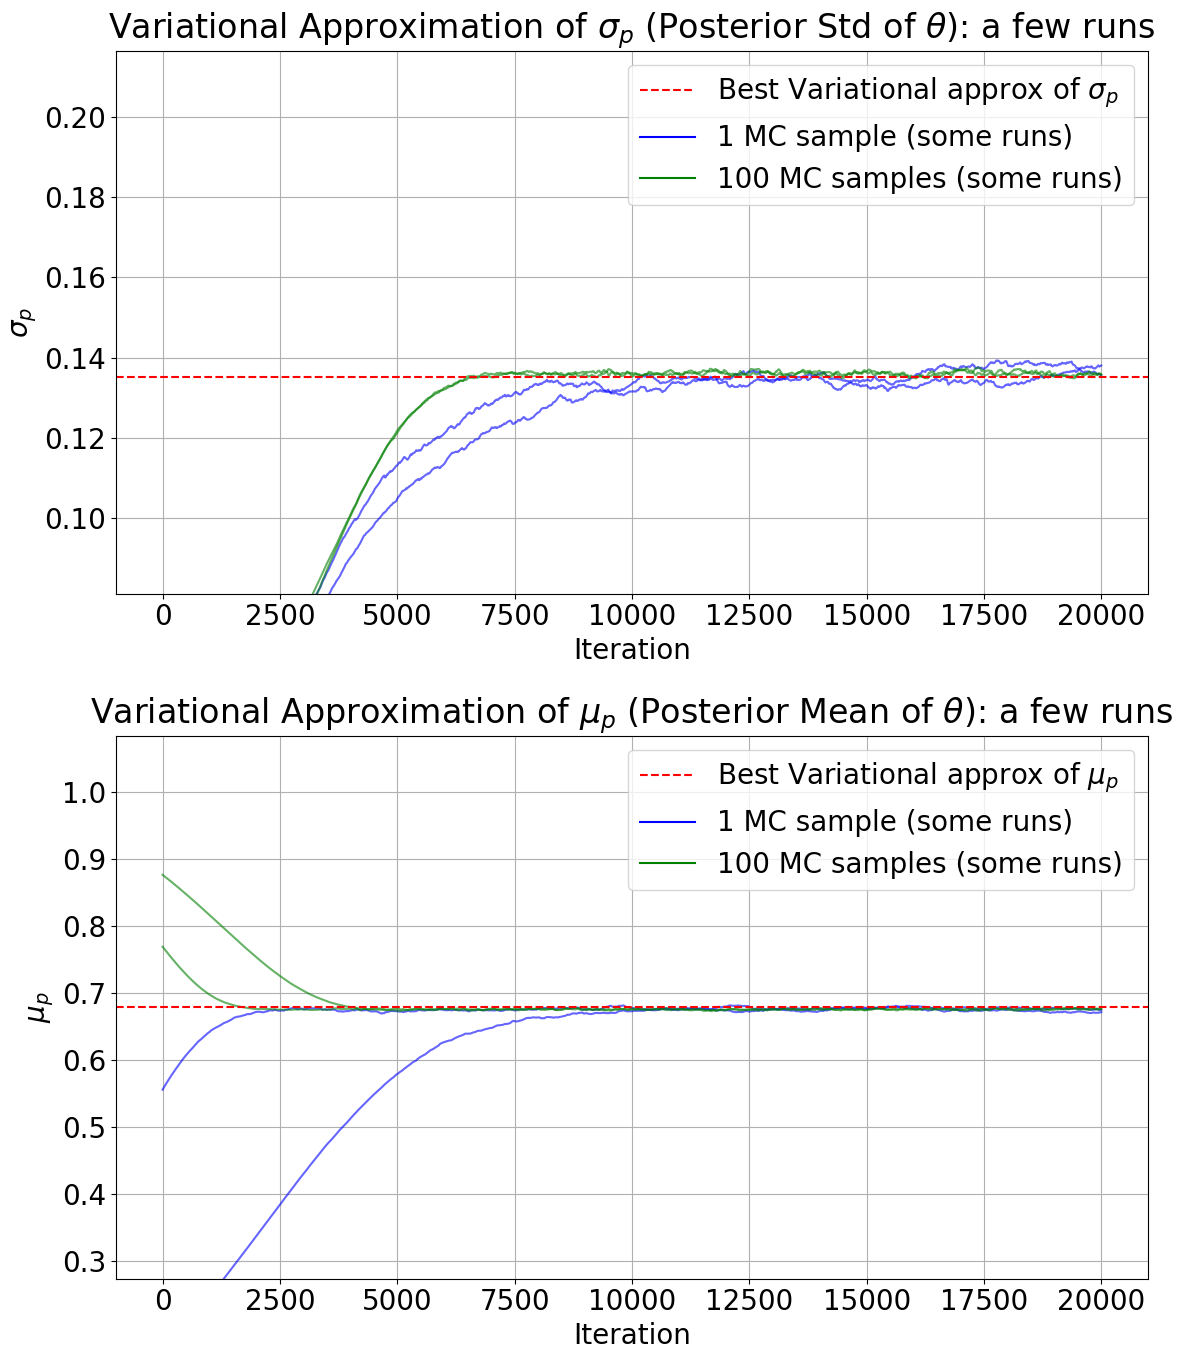

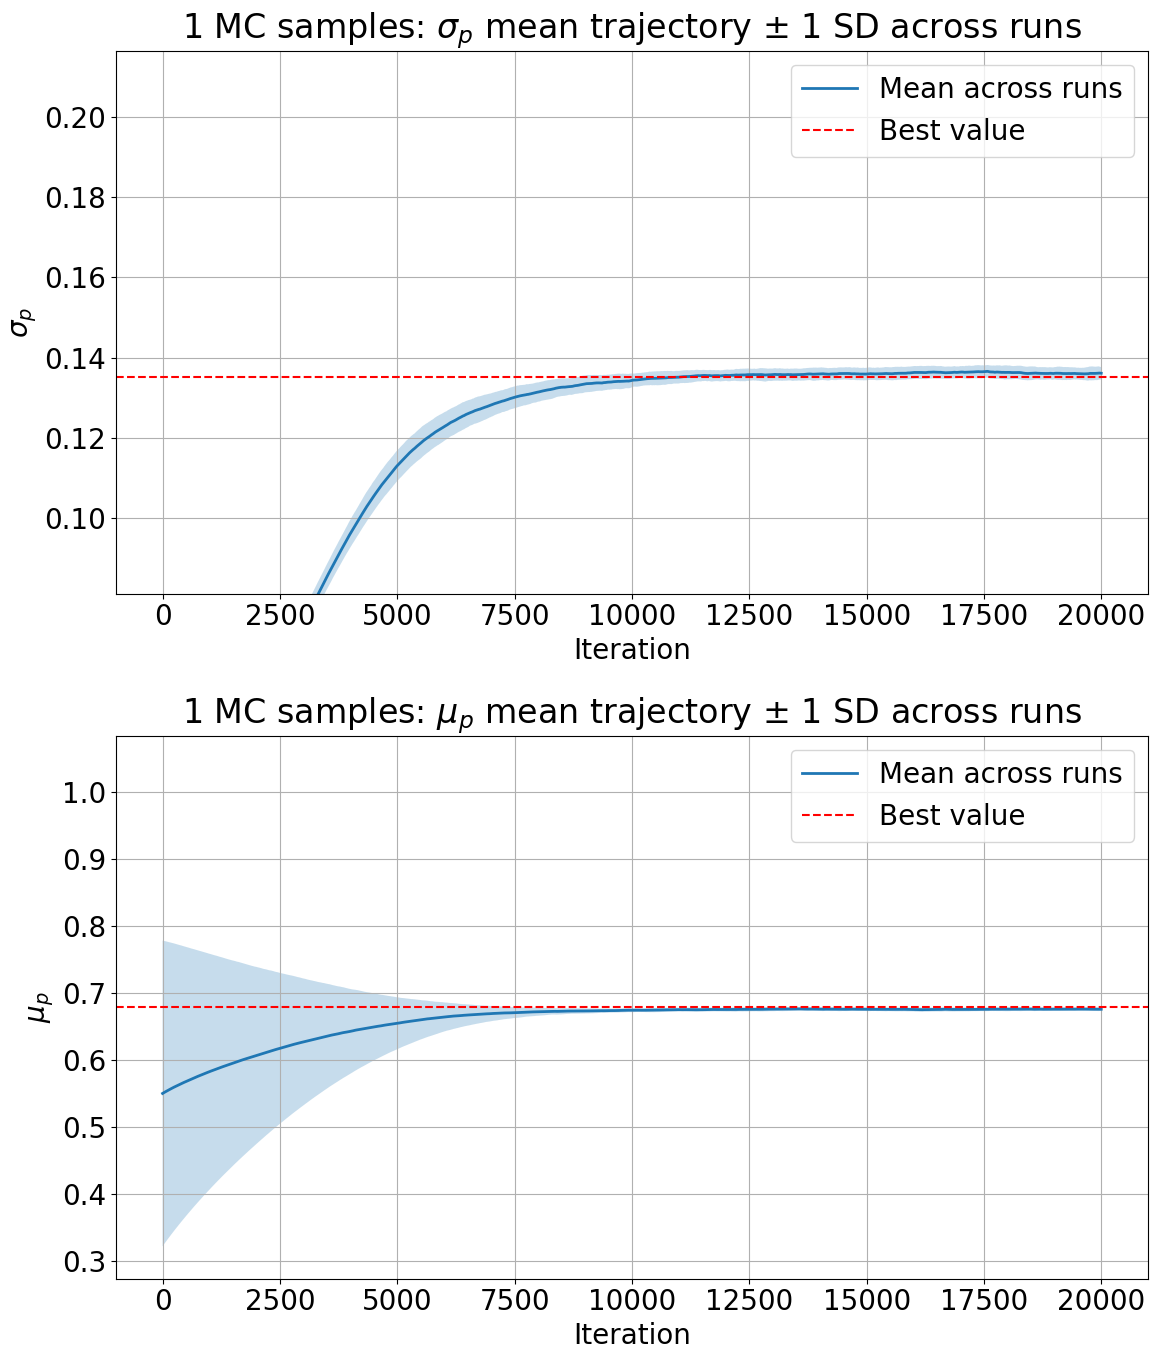

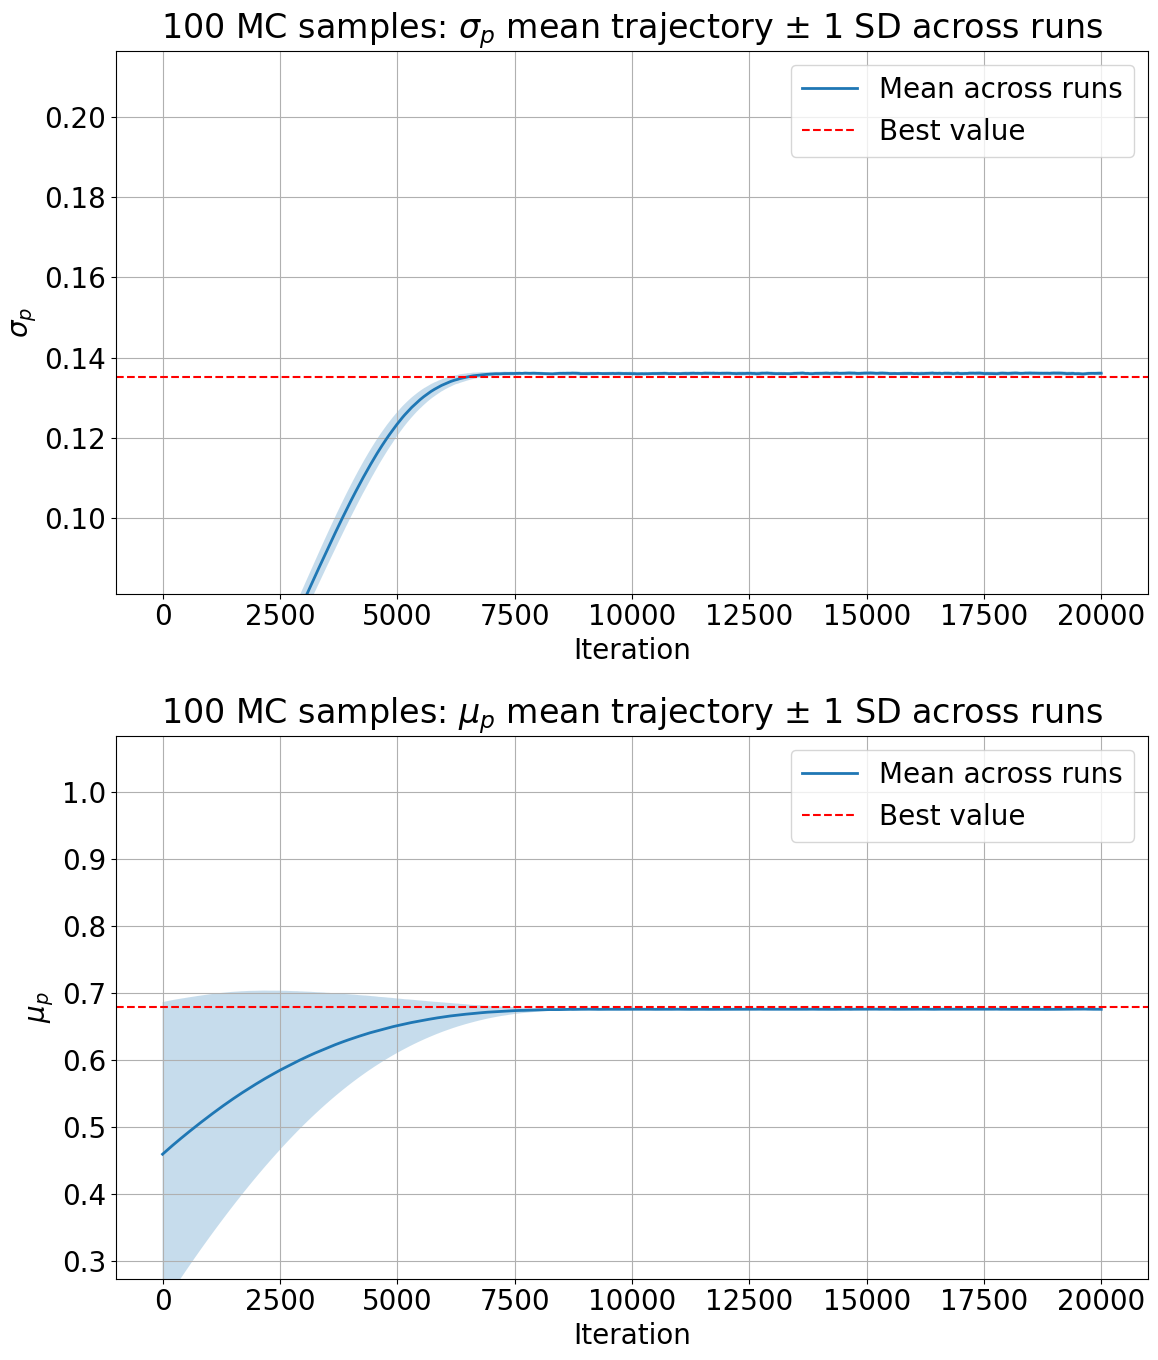

In [37]:
from modulars import plot_a_few_trajectories_1d, plot_mean_band_rrs_1d
plot_a_few_trajectories_1d(
    [single_means, single_stds], [multi_means, multi_stds],
    best_mu, best_std, r'$\theta$')
plot_mean_band_rrs_1d(
    single_means, single_stds, best_mu, best_std,
    x, r'$\theta$', 1)
plot_mean_band_rrs_1d(
    multi_means, multi_stds, best_mu, best_std,
    x, r'$\theta$', 100)


In [38]:
multi_stds[0][10000:10100]

array([0.13609515, 0.13607085, 0.13605452, 0.13603538, 0.13602418,
       0.13601564, 0.13599709, 0.13598032, 0.13597244, 0.13596338,
       0.13596165, 0.13597089, 0.1359781 , 0.13599062, 0.13600053,
       0.136012  , 0.13601933, 0.13602781, 0.13604307, 0.13605078,
       0.13605721, 0.13606362, 0.13607368, 0.13607219, 0.136063  ,
       0.1360488 , 0.13602817, 0.13601547, 0.13600877, 0.13599351,
       0.13597876, 0.13597402, 0.13597141, 0.13597044, 0.13597131,
       0.13597055, 0.13597564, 0.13597344, 0.13596295, 0.13596061,
       0.13595903, 0.13595574, 0.13596046, 0.13596268, 0.1359627 ,
       0.13596627, 0.1359767 , 0.13598683, 0.13600156, 0.1360129 ,
       0.1360285 , 0.13603784, 0.13604775, 0.13606308, 0.13608085,
       0.13609074, 0.13610873, 0.13612922, 0.13614634, 0.1361612 ,
       0.13617449, 0.13617924, 0.13619192, 0.13619733, 0.13620745,
       0.13620953, 0.1362025 , 0.13619743, 0.13619399, 0.13619332,
       0.13619104, 0.13618529, 0.13618502, 0.13618676, 0.13618